In [2]:
from sklearn.datasets import make_regression 

%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation 
import matplotlib.animation as animation 

In [3]:
X,y = make_regression(n_samples=100,n_targets=1,n_features=1,n_informative=1,noise=20,random_state=13)

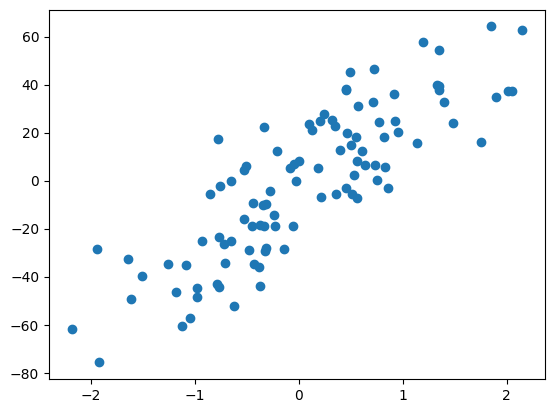

In [4]:
plt.scatter(X,y)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_) # value of m 
print(lr.intercept_) # value of b

[27.82809103]
-2.29474455867698


In [6]:
print(X.shape[0])

100


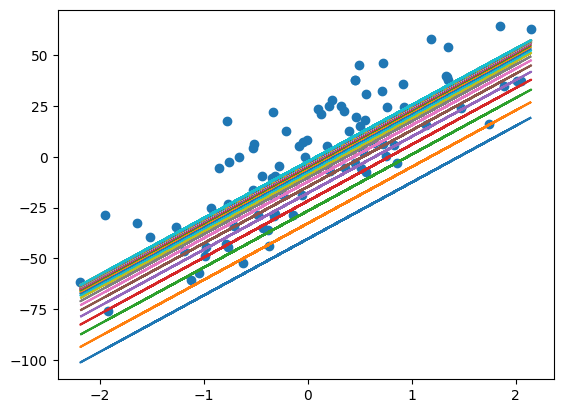

In [7]:
b = -50
m = 27.82
lr = 0.001
all_b = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope = 0
    cost = 0
    for j in range(X.shape[0]):
        slope = slope - 2*(y[j]-(m*X[j])-b)
        cost = cost+(y[j]-m*X[j]-b)**2

    b = b - (lr*slope)
    all_b.append(b)
    all_cost.append(cost)
    y_pred = m*X+b
    plt.plot(X,y_pred)

plt.scatter(X,y)
# in the below graph all the points are the scatter points of the data and there are different lines , the line which is below number 1 is the line having value of b as -50 and then for each iteration the value of b get changes and because of that the line get shift up by some amount 

In [8]:
all_b

[array([-40.4588544]),
 array([-32.82593791]),
 array([-26.71960473]),
 array([-21.83453818]),
 array([-17.92648494]),
 array([-14.80004235]),
 array([-12.29888827]),
 array([-10.29796502]),
 array([-8.69722641]),
 array([-7.41663552]),
 array([-6.39216282]),
 array([-5.57258465]),
 array([-4.91692212]),
 array([-4.39239209]),
 array([-3.97276807]),
 array([-3.63706885]),
 array([-3.36850948]),
 array([-3.15366198]),
 array([-2.98178398]),
 array([-2.84428158]),
 array([-2.73427966]),
 array([-2.64627812]),
 array([-2.5758769]),
 array([-2.51955591]),
 array([-2.47449913]),
 array([-2.4384537]),
 array([-2.40961736]),
 array([-2.38654828]),
 array([-2.36809302]),
 array([-2.35332881])]

In [9]:
all_b = np.array(all_b).ravel()
all_b

array([-40.4588544 , -32.82593791, -26.71960473, -21.83453818,
       -17.92648494, -14.80004235, -12.29888827, -10.29796502,
        -8.69722641,  -7.41663552,  -6.39216282,  -5.57258465,
        -4.91692212,  -4.39239209,  -3.97276807,  -3.63706885,
        -3.36850948,  -3.15366198,  -2.98178398,  -2.84428158,
        -2.73427966,  -2.64627812,  -2.5758769 ,  -2.51955591,
        -2.47449913,  -2.4384537 ,  -2.40961736,  -2.38654828,
        -2.36809302,  -2.35332881])

In [ ]:
all_cost = np.array(all_cost).ravel()
all_cost

array([255925.92985413, 173995.81636992, 121560.54374003,  88001.9692569 ,
        66524.48158769,  52778.8894794 ,  43981.7105301 ,  38351.51600254,
        34748.1915049 ,  32442.06382642,  30966.14211219,  30021.55221508,
        29417.01468093,  29030.11065907,  28782.49208508,  28624.01619773,
        28522.59162983,  28457.67990637,  28416.13640335,  28389.54856143,
        28372.53234259,  28361.64196254,  28354.6721193 ,  28350.21141963,
        28347.35657184,  28345.52946926,  28344.3601236 ,  28343.61174238,
        28343.1327784 ,  28342.82624146])

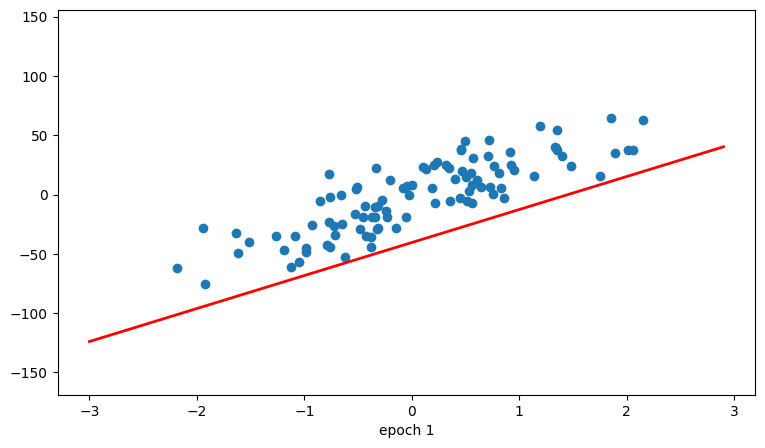

In [11]:
fig, ax = plt.subplots(figsize=(9,5))
#fig.set_tight_layout(True)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m -150
ax.scatter(X, y)
line, = ax.plot(x_i, x_i*50 - 4, 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m + all_b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)

#f = r"animation.gif" 
#writergif = animation.PillowWriter(fps=2) 
#anim.save(f, writer=writergif)